[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Why Images Need a Different Architecture

A fully connected network assumes nothing about its input: every unit reads every unit in the preceding layer, and permuting the inputs changes nothing except the order of the weights.  That is the right default when the input is an unstructured list of features. It is the wrong one for language, which is what both of the architectures we built for sequences were answers to.  The recurrent network threaded information along the sequence one step at a time; the transformer let every position attend to every other, with positional encodings to say where each one sat.  These are different mechanisms with one underlying idea: find the structure in the data and build it into the architecture.

Images have structure too, and it is not the structure of a sequence.  A pixel in an image has neighbours (above, below, left, right) and the values in those neighboring pixels are highly correlated.  In this module we describe an architecture that is specifically adapted to represent images, and furthermore, takes cues from the successes of the great success of the biological visual system and incorporates that into the architecture.

The case against MLPs for image data is easy to state.  An MLP takes a vector as input, so an image must be **flattened** — the $28 \times 28$ grid becomes a $784$-dimensional vector, and the fact that pixel $(5,5)$ sits next to pixel $(5,6)$ is discarded before the network sees anything.

For a long time this was worked around rather than fixed.  Practitioners hand-designed *features* — edge histograms, corner detectors, texture statistics — fed those to a classifier, and the quality of a vision system was largely the quality of its designer's intuitions.  Then, in the 2012 ImageNet competition (1000 classes, over 1.4 million images), a convolutional network from Geoff Hinton's group cut the error rate to 16% where the closest competitor, built on engineered features, managed 26%.  That success got the research community's attention and sparked the deep learning revolution.

To motivate the architecture of convolutional networks we will start with three demonstrations of what is wrong with using fully connected networks directly on image pixel data:

1. **Pixel space is the wrong space.** Two images that look alike to us can be far apart pixel by pixel.
2. **A fully connected network cannot see spatial structure.** We will demonstrate this by scrambling every image and watching the accuracy not change.
3. **MLPs are highly inefficient for images.** The number of parameters increases with increasing resolution, making this approach infeasible for realistically sized images.

Then we will look at how biological vision handles the same problem, and end with the design principles that underly convolutional networks, the architecture that addresses these shortcomings.

In this notebook we will use both the original MNIST digit recognition dataset as well as the more modern Fashion-MNIST.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

In [2]:
data_dir = '../data'
transform = transforms.ToTensor()   # (1, 28, 28) float tensors in [0, 1]
train_set = datasets.FashionMNIST(data_dir, train=True, download=True,
                                  transform=transform)
val_set = datasets.FashionMNIST(data_dir, train=False, download=True,
                                transform=transform)
labels = train_set.classes
print(f'{len(train_set)} training and {len(val_set)} validation images '
      f'of shape {tuple(train_set[0][0].shape)}')
print('classes:', ', '.join(labels))

60000 training and 10000 validation images of shape (1, 28, 28)
classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


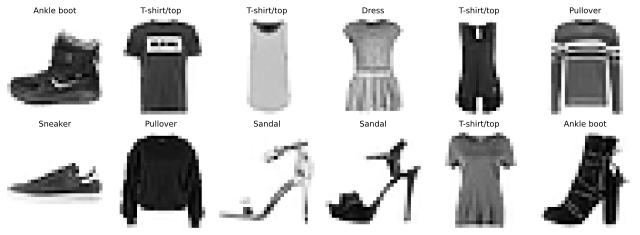

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
for ax, (image, label) in zip(axes.flatten(), train_set):
    ax.imshow(image.squeeze(), cmap='Greys', interpolation='nearest')
    ax.set_title(labels[label], fontsize=8)
    ax.axis('off')
fig.tight_layout()

## The invariance problem

Our perceptual system is extremely good at ignoring things that change while the object stays the same:

* **translation** — the object moves within the frame
* **rotation** and **scaling** — it turns, or comes nearer
* **deformation** — a shirt is a shirt whether folded, stretched, or on a person
* **contrast** and **lighting** — the same scene at dusk and at noon

We are so good at this that it takes some effort to appreciate how hard it is.  Recognizing a coat as a coat under all of those transformations means recognizing that a *huge* set of very different pixel arrays all denote the same thing.

### The pixel shift conundrum

Consider the following experiment using the original MNIST dataset.  The code cell below shows three images, two of them of the same digit, except that one has been shifted by a few pixels, and a third which is of a different digit entirely.  We then ask the question of which one is closer in pixel space to the first image.

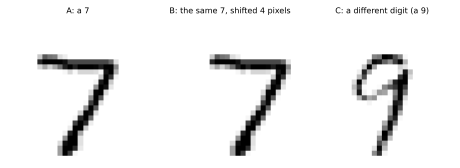

In [4]:
digit_set = datasets.MNIST(data_dir, train=False, download=True,
                           transform=transform)

n_digits = 500
digits = torch.stack([digit_set[i][0] for i in range(n_digits)])
digit_labels = torch.tensor([digit_set[i][1] for i in range(n_digits)])

# all pairwise distances, and each image's nearest neighbour of another class
D = torch.cdist(digits.flatten(1), digits.flatten(1))
other_class = digit_labels[:, None] != digit_labels[None, :]
D_other = D.masked_fill(~other_class, float('inf'))
nearest_idx, nearest_dist = D_other.argmin(dim=1), D_other.min(dim=1).values

# distance from each digit to a shifted copy of itself
shift = 4
shifted = torch.roll(digits, shift, dims=3)
self_dist = (digits - shifted).flatten(1).norm(dim=1)

# take the first digit for which the shifted copy is the farther of the two
candidates = (self_dist > nearest_dist).nonzero().flatten()
i = int(candidates[0]) if len(candidates) else int((self_dist - nearest_dist).argmax())
j = int(nearest_idx[i])

A, B, C = digits[i], shifted[i], digits[j]

fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.6))
for ax, image, title in zip(axes, [A, B, C],
                            [f'A: a {digit_labels[i]}',
                             f'B: the same {digit_labels[i]}, '
                             f'shifted {shift} pixels',
                             f'C: a different digit (a {digit_labels[j]})']):
    ax.imshow(image.squeeze(), cmap='Greys', interpolation='nearest')
    ax.set_title(title, fontsize=8)
    ax.axis('off')
fig.tight_layout()

In [5]:
d_AB = (A - B).norm().item()
d_AC = (A - C).norm().item()
print(f'distance from digit to shifted digit:     {d_AB:5.2f}')
print(f'distance from digit to a different digit: {d_AC:5.2f}')

distance from digit to shifted digit:      9.18
distance from digit to a different digit:  7.13


In pixel space, the digit is closer to a **different digit** than it is to itself moved four pixels!

A representation with this property cannot support any classifier that relies on nearness, however sophisticated the classifier is.

### Is that example typical?

One picked example proves nothing, so let's measure it across a dataset — back to Fashion-MNIST, where the same effect appears.  We compare the distance from an image to a shifted copy of itself against two baselines: the distance to the *average* garment of another class, and the distance to the *nearest* one.

In [6]:
# 400 validation images, flattened, and their labels
sample = torch.stack([val_set[i][0] for i in range(400)]).flatten(1)
sample_labels = torch.tensor([val_set[i][1] for i in range(400)])
images = sample.reshape(-1, 1, 28, 28)

# 1. how far does an image move when we shift it k pixels to the right?
shifts = range(0, 9)
shift_distances = [
    (images - torch.roll(images, k, dims=3)).flatten(1).norm(dim=1).mean().item()
    for k in shifts]

# 2. how far apart are two garments of *different* classes, on average?
D = torch.cdist(sample, sample)                    # all pairwise distances
different = sample_labels[:, None] != sample_labels[None, :]
between_class = D[different].mean().item()

# 3. and how far is each image from the *nearest* garment of another class?
#    (the distance a nearest-neighbour classifier would have to beat)
nearest_other = D.masked_fill(~different, float('inf')).min(dim=1).values.mean().item()

for k, d in zip(shifts, shift_distances):
    print(f'shift of {k} pixels:         mean distance {d:5.2f}')
print(f'\nnearest garment of another class: {nearest_other:5.2f}')
print(f'average garment of another class: {between_class:5.2f}')

for name, baseline in [('the nearest', nearest_other),
                       ('the average', between_class)]:
    k = next((k for k, d in zip(shifts, shift_distances) if d > baseline), None)
    print(f'a shift of {k} pixels moves an image farther than {name} '
          f'garment of another class' if k is not None else
          f'no shift up to {max(shifts)} pixels exceeds {name} garment')

shift of 0 pixels:         mean distance  0.00
shift of 1 pixels:         mean distance  5.32
shift of 2 pixels:         mean distance  7.39
shift of 3 pixels:         mean distance  8.57
shift of 4 pixels:         mean distance  9.47
shift of 5 pixels:         mean distance 10.16
shift of 6 pixels:         mean distance 10.86
shift of 7 pixels:         mean distance 11.50
shift of 8 pixels:         mean distance 12.04

nearest garment of another class:  6.03
average garment of another class: 11.74
a shift of 2 pixels moves an image farther than the nearest garment of another class
a shift of 8 pixels moves an image farther than the average garment of another class


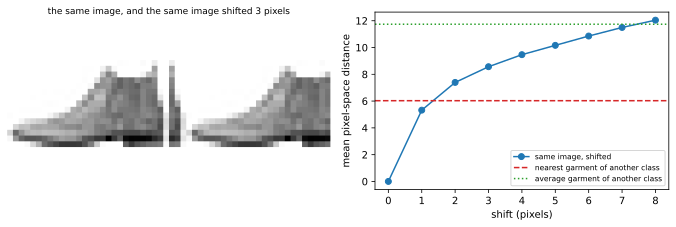

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.2),
                               gridspec_kw={'width_ratios': [1.1, 1]})

# left: what a few pixels of shift actually looks like
original = val_set[0][0]
ax1.imshow(torch.cat([original.squeeze(),
                      torch.roll(original, 3, dims=2).squeeze()], dim=1),
           cmap='Greys', interpolation='nearest')
ax1.set_title('the same image, and the same image shifted 3 pixels',
              fontsize=9)
ax1.axis('off')

# right: distance as a function of shift, against the two baselines
ax2.plot(list(shifts), shift_distances, 'o-', color='C0',
         label='same image, shifted')
ax2.axhline(nearest_other, color='C3', ls='--',
            label='nearest garment of another class')
ax2.axhline(between_class, color='C2', ls=':',
            label='average garment of another class')
ax2.set_xlabel('shift (pixels)')
ax2.set_ylabel('mean pixel-space distance')
ax2.legend(fontsize=7.5)
fig.tight_layout()

The digit example was not a fluke.  Within a few pixels of shift — read the exact point off the printout — the blue curve crosses the dashed line, and the effect is an average over hundreds of images rather than a lucky pair.

The dashed line is the one that stings.  A nearest-neighbour classifier in pixel space assigns an image the label of whatever is closest to it, so once the shift curve rises above that line, a slightly displaced garment is closer to some *other* category than to anything resembling itself.  The classifier does not have a hard problem here; it has an impossible one.

## What does a fully connected network see?

**Claim:** a fully connected network is *blind* to the spatial arrangement of its input.  If that sounds familiar, it should: it is the image version of the word-order experiment from the attention module, where a transformer without positional encodings gave identical scores to a review and to a scrambling of the same words.  To test this, we will pick a fixed permutation of the 784 pixel positions, apply it to every image in the dataset, and train.  If the network was relying on spatial structure, destroying that structure should affect its accuracy.

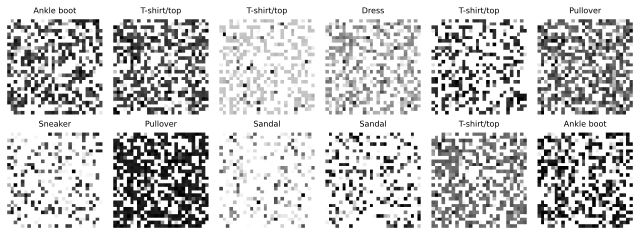

In [8]:
torch.manual_seed(0)
perm = torch.randperm(28 * 28)      # one permutation, reused for every image

def permute_pixels(image):
    """Shuffle an image's pixels with the fixed permutation `perm`."""
    return image.flatten()[perm].reshape(1, 28, 28)

fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
for ax, (image, label) in zip(axes.flatten(), train_set):
    ax.imshow(permute_pixels(image).squeeze(), cmap='Greys', interpolation='nearest')
    ax.set_title(labels[label], fontsize=8)
    ax.axis('off')
fig.tight_layout()

To us these are noise; not one of them is recognizable.  The question is whether they are noise to an MLP.

In [9]:
device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using {device} device')

Using mps device


In [10]:
def make_mlp():
    """A two-hidden-layer MLP over flattened 28 x 28 images."""
    return nn.Sequential(nn.Flatten(),
                         nn.Linear(784, 256), nn.ReLU(),
                         nn.Linear(256, 128), nn.ReLU(),
                         nn.Linear(128, 10))

def train_mlp(shuffle_pixels, epochs=3, batch_size=256, lr=0.1, seed=0):
    """Train an MLP on Fashion-MNIST; optionally permute every image's pixels.
    Returns the final validation accuracy."""
    torch.manual_seed(seed)                 # same initialization either way
    model = make_mlp().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    train_iter = DataLoader(train_set, batch_size, shuffle=True)
    val_iter = DataLoader(val_set, batch_size)

    for epoch in range(epochs):
        model.train()
        for X, y in train_iter:
            if shuffle_pixels:
                X = X.flatten(1)[:, perm].reshape(X.shape)
            X, y = X.to(device), y.to(device)
            loss = loss_fn(model(X), y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    correct = total = 0
    for X, y in val_iter:
        if shuffle_pixels:
            X = X.flatten(1)[:, perm].reshape(X.shape)
        X, y = X.to(device), y.to(device)
        with torch.no_grad():
            correct += (model(X).argmax(dim=1) == y).sum().item()
        total += y.numel()
    return correct / total

In [11]:
acc_plain = train_mlp(shuffle_pixels=False)
acc_shuffled = train_mlp(shuffle_pixels=True)
print(f'validation accuracy, original images:  {acc_plain:.3f}')
print(f'validation accuracy, shuffled pixels:  {acc_shuffled:.3f}')

validation accuracy, original images:  0.820
validation accuracy, shuffled pixels:  0.821


The two numbers are essentially the same.  This is the case since the output of the network is invariant to a simultaneous permutation of the inputs and permuting and the columns of the first weight matrix.  So for any MLP trained on the original images there is a corresponding MLP, with permuted first-layer columns, achieving *exactly* the same accuracy on the scrambled ones.

Whatever an MLP has learned about images, none of it depends on which pixels are adjacent, the very structure that we, looking at the two figures above, depend on entirely.  A good architecture for images should fail this test badly.  (A later exercise asks you to run this same test on the CNN we build in notebook 6.)

## Counting the parameters

The third problem is size.  To see that, consider a layer connected directly to the input.


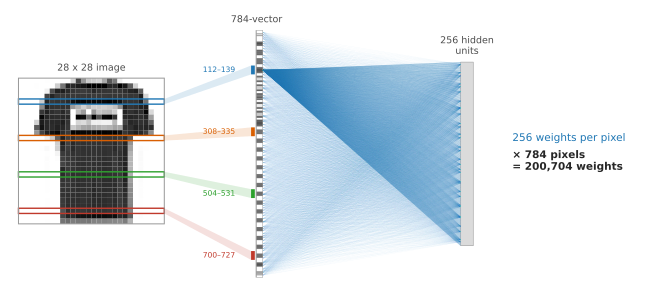

In [12]:
from matplotlib.collections import LineCollection
from matplotlib.patches import Polygon, Rectangle

BAND = ['#1f77b4', '#d95f02', '#2ca02c', '#c0392b']

def flatten_figure(img, num_hidden=256, rows=(4, 11, 18, 25),
                   pixel_step=8, hidden_step=8):
    img = np.asarray(img).squeeze()
    n = img.shape[0]
    n_pixels = n * n
    flat = img.reshape(-1)
    bands = list(zip(BAND, rows))

    fig = plt.figure(figsize=(9, 4))
    ax_img = fig.add_axes([0.015, 0.15, 0.23, 0.70])
    ax_vec = fig.add_axes([0.375, 0.06, 0.020, 0.86])
    ax_hid = fig.add_axes([0.700, 0.17, 0.020, 0.64])
    ax_ov = fig.add_axes([0, 0, 1, 1], facecolor='none', zorder=0)
    ax_ov.set_xlim(0, 1); ax_ov.set_ylim(0, 1); ax_ov.axis('off')

    # ---- the image, one vector rectangle per pixel ------------------------
    ax_img.set_xlim(-0.3, n + 0.3); ax_img.set_ylim(n + 0.3, -0.3)
    ax_img.set_aspect('equal'); ax_img.axis('off')
    for i in range(n):
        for j in range(n):
            v = 1 - float(img[i, j])
            ax_img.add_patch(Rectangle((j, i), 1, 1, facecolor=(v, v, v),
                                       edgecolor='none'))
    for c, r in bands:
        ax_img.add_patch(Rectangle((0, r), n, 1, fill=False, edgecolor=c,
                                   lw=1.4))
    ax_img.add_patch(Rectangle((0, 0), n, n, fill=False, edgecolor='0.6',
                               lw=1.0))
    ax_img.set_title(f'{n} x {n} image', fontsize=9.5, color='0.3')

    # ---- the vector: the same pixels, still legible as stripes ------------
    ax_vec.set_xlim(-0.9, 1); ax_vec.set_ylim(n_pixels, 0); ax_vec.axis('off')
    for p in range(n_pixels):
        v = 1 - float(flat[p])
        ax_vec.add_patch(Rectangle((0, p), 1, 1, facecolor=(v, v, v),
                                   edgecolor='none'))
    ax_vec.add_patch(Rectangle((0, 0), 1, n_pixels, fill=False,
                               edgecolor='0.6', lw=1.0))
    for c, r in bands:      # marked in the margin, so the stripes show through
        ax_vec.add_patch(Rectangle((-0.75, r * n), 0.55, n, facecolor=c,
                                   edgecolor='none'))
    ax_vec.set_title(f'{n_pixels}-vector', fontsize=9.5, color='0.3', pad=8)

    ax_hid.set_xlim(0, 1); ax_hid.set_ylim(num_hidden, 0); ax_hid.axis('off')
    ax_hid.add_patch(Rectangle((0, 0), 1, num_hidden, facecolor='0.86',
                               edgecolor='0.6', lw=1.0))
    ax_hid.set_title(f'{num_hidden} hidden\nunits', fontsize=9.5, color='0.3',
                     pad=8)

    # ax_img has aspect='equal', so matplotlib resizes its box during the
    # draw.  Force that now: until it happens, transData is stale and anything
    # positioned through it lands in the wrong place.
    fig.canvas.draw()

    def to_fig(ax, x, y):
        return fig.transFigure.inverted().transform(
            ax.transData.transform((x, y)))

    # ---- ribbons: each traced row flows into 28 adjacent slots ------------
    for c, r in bands:
        ax_ov.add_patch(Polygon([to_fig(ax_img, n, r),
                                 to_fig(ax_vec, -0.75, r * n),
                                 to_fig(ax_vec, -0.75, (r + 1) * n),
                                 to_fig(ax_img, n, r + 1)], closed=True,
                                facecolor=c, alpha=0.16, edgecolor='none',
                                transform=fig.transFigure, zorder=0))

    # ---- every pixel to every hidden unit ---------------------------------
    # jitter the endpoints: exactly evenly spaced sources and targets
    # interfere and band the fan, while fully random ones make it scribbly
    rng = np.random.default_rng(0)
    src_idx = [min(n_pixels - 1, p + int(rng.integers(0, pixel_step)))
               for p in range(0, n_pixels, pixel_step)]
    tgt_idx = [min(num_hidden - 1, u + int(rng.integers(0, hidden_step)))
               for u in range(0, num_hidden, hidden_step)]
    targets = [to_fig(ax_hid, 0.0, u + 0.5) for u in tgt_idx]
    segs = [[to_fig(ax_vec, 1.0, p + 0.5), t]
            for p in src_idx for t in targets]
    ax_ov.add_collection(LineCollection(segs, colors='#1f77b4', linewidths=0.3,
                                        alpha=0.05, zorder=1,
                                        transform=fig.transFigure))
    # one pixel's own 256 connections, picked out of the crowd
    focus = rows[0] * n + n // 2
    src = to_fig(ax_vec, 1.0, focus + 0.5)
    ax_ov.add_collection(LineCollection(
        [[src, to_fig(ax_hid, 0.0, u + 0.5)] for u in range(num_hidden)],
        colors=BAND[0], linewidths=0.45, alpha=0.5, zorder=2,
        transform=fig.transFigure))

    # ---- annotation --------------------------------------------------------
    for c, r in bands:
        y = to_fig(ax_vec, -0.75, (r + 0.5) * n)[1]
        ax_ov.text(0.352, y, f'{r * n}–{r * n + n - 1}', fontsize=7.5,
                   color=c, va='center', ha='right')
    # one running statement, so keep the two lines the same size and close
    fig.text(0.78, 0.545, f'{num_hidden} weights per pixel', fontsize=10.5,
             color=BAND[0], va='center')
    fig.text(0.78, 0.465, f'× {n_pixels} pixels\n= {n_pixels * num_hidden:,}'
             f' weights', fontsize=10.5, color='0.15', va='center',
             fontweight='bold')

flatten_figure(train_set[1][0]);

Two hundred thousand weights, for one layer, on a $28 \times 28$ thumbnail.  It gets worse when considering more realistic image size.  Suppose we want to tell cats from dogs in one-megapixel photographs.  Each input has $10^6$ dimensions; even an aggressive reduction to a thousand hidden units needs $10^6 \times 10^3 = 10^9$ parameters, again for a single layer.  Reducing the resolution helps the arithmetic but not the argument: a hidden layer of 1000 units badly underestimates what representing an image takes, so a practical system still lands in the billions — and fitting that many parameters demands a correspondingly enormous dataset.

The trouble is the *shape* of the growth.  Every pixel connects to every hidden unit, so the parameter count grows with the **area** of the image: double the resolution and it quadruples.

       image      pixels        parameters
       28x28         784           784,000
       64x64       4,096         4,096,000
     128x128      16,384        16,384,000
     256x256      65,536        65,536,000
     512x512     262,144       262,144,000
   1024x1024   1,048,576     1,048,576,000


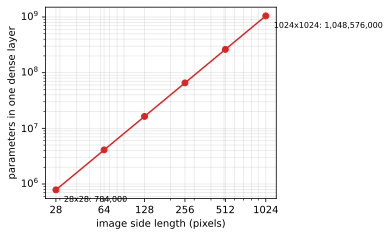

In [13]:
sides = np.array([28, 64, 128, 256, 512, 1024])
dense = sides ** 2 * 1000        # 1000 hidden units, fully connected

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.loglog(sides, dense, 'o-', color='C3')
ax.set_xlabel('image side length (pixels)')
ax.set_ylabel('parameters in one dense layer')
ax.set_xticks(sides); ax.set_xticklabels(sides)
ax.grid(alpha=0.3, which='both')
for n in (28, 1024):
    ax.annotate(f'{n}x{n}: {n ** 2 * 1000:,}', (n, n ** 2 * 1000),
                textcoords='offset points', xytext=(8, -12), fontsize=8)
fig.tight_layout()

print(f'{"image":>12s}  {"pixels":>10s}  {"parameters":>16s}')
for n in sides:
    print(f'{f"{n}x{n}":>12s}  {n ** 2:>10,d}  {n ** 2 * 1000:>16,d}')

A billion parameters in the first layer alone, for one megapixel.  This is more parameters than a typical dataset has pixels.  We cannot fit that, and we should not want to: a model with that much freedom will find some way to memorize its training set.

So we need a way of building layers whose parameter count does *not* grow with the size of the image, and which does not throw the spatial structure away.  For ideas on how to do that, let's look at a system that already solves this problem.

## A clue from biology

Visual processing in the brain is organized as a **hierarchy of increasing abstraction**, and two structural facts about it are worth borrowing.

A neuron in the visual system does not look at the whole scene.  It reads a small window — its **receptive field**.   Within that window it is *selective*: it responds strongly to a particular pattern, its **preferred stimulus**, and weakly to everything else.  Hubel and Wiesel established what that pattern is for the primary visual cortex (V1) in work that won them a share of the 1981 Nobel Prize.  In the early layer of the visual system, V1, neurons fire when there is an **edge at a particular orientation** in its patch of the visual field.

A visual neuron is therefore a **local detector**: a small window, plus a question asked about its contents.

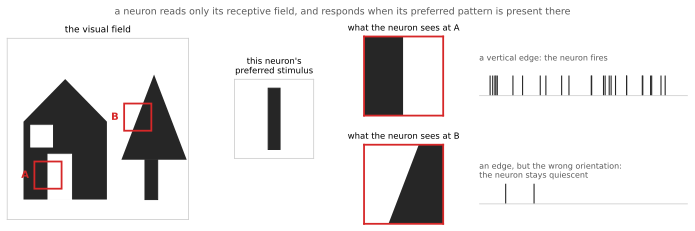

In [14]:
from matplotlib.patches import Circle, Polygon, Rectangle, Wedge, Arc
from matplotlib.transforms import Affine2D

INK = '0.15'

# These figures are drawn with vector patches rather than imshow, so that the
# SVG output stays crisp instead of embedding a resampled bitmap.

def blank(ax, lim=1.0):
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor('0.8')

def bar(ax, deg, length=1.55, width=0.30, x0=None, y0=0.0):
    # a bar at the given orientation, centred unless x0 is given
    x0 = -length / 2 if x0 is None else x0
    p = Rectangle((x0, y0 - width / 2), length, width, color=INK)
    p.set_transform(Affine2D().rotate_deg(deg) + ax.transData)
    ax.add_patch(p)

def ray(ax, deg, length=0.85, width=0.28):
    # a bar starting at the origin and pointing outwards
    bar(ax, deg, length=length, width=width, x0=-width / 2)

def poly(ax, pts):
    ax.add_patch(Polygon(np.asarray(pts), closed=True, facecolor=INK,
                         edgecolor='none'))

def curve_pts(f, t0, t1, n=200):
    t = np.linspace(t0, t1, n)
    return np.column_stack([f(t) * np.cos(t), f(t) * np.sin(t)])

def scene(ax):
    # a house with clean vertical edges, and a tree with clean diagonal ones
    poly(ax, [(-0.82, -0.78), (-0.82, 0.08), (-0.36, 0.55), (0.10, 0.08),
              (0.10, -0.78)])
    ax.add_patch(Rectangle((-0.55, -0.78), 0.26, 0.5, color='white'))
    ax.add_patch(Rectangle((-0.74, -0.20), 0.24, 0.24, color='white'))
    ax.add_patch(Rectangle((0.52, -0.78), 0.14, 0.44, color=INK))
    poly(ax, [(0.62, 0.60), (0.98, -0.34), (0.26, -0.34)])

fig = plt.figure(figsize=(10, 3.5))
# A straddles a vertical edge of the door; B straddles the tree's diagonal
# edge -- an edge, but not the one this cell is tuned to
boxes = {'A': (-0.70, -0.66, 0.30), 'B': (0.29, -0.02, 0.30)}

ax = fig.add_axes([0.02, 0.14, 0.28, 0.72])
blank(ax); scene(ax)
for name, (bx, by, s) in boxes.items():
    ax.add_patch(Rectangle((bx, by), s, s, fill=False, edgecolor='C3', lw=1.8))
    ax.text(bx - 0.06, by + s / 2, name, ha='right', va='center', fontsize=10,
            color='C3', fontweight='bold')
ax.set_title('the visual field', fontsize=9)

ax = fig.add_axes([0.35, 0.36, 0.11, 0.36])
blank(ax); bar(ax, 90)
ax.set_title("this neuron's\npreferred stimulus", fontsize=8.5)

for name, y, caption, n_spikes in [
        ('A', 0.53, 'a vertical edge: the neuron fires', 26),
        ('B', 0.10, 'an edge, but the wrong orientation:\n'
                    'the neuron stays quiescent', 2)]:
    bx, by, s = boxes[name]
    ax = fig.add_axes([0.53, y, 0.11, 0.36])
    blank(ax); scene(ax)
    ax.set_xlim(bx, bx + s); ax.set_ylim(by, by + s)   # zoom to the window
    for spine in ax.spines.values():
        spine.set_edgecolor('C3'); spine.set_linewidth(1.8)
    ax.set_title(f'what the neuron sees at {name}', fontsize=8.5)

    ax = fig.add_axes([0.69, y + 0.09, 0.29, 0.18])
    rng = np.random.default_rng(0 if name == 'A' else 3)
    ax.vlines(np.sort(rng.uniform(0.05, 0.95, n_spikes)), 0, 1, color=INK,
              lw=1.1)
    ax.set_xlim(0, 1); ax.set_ylim(-0.15, 2.1)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.axhline(0, color='0.8', lw=0.8)
    ax.text(0, 2.05, caption, fontsize=8, color='0.35', va='top')

fig.text(0.5, 0.955, 'a neuron reads only its receptive field, and responds '
         'when its preferred pattern is present there',
         ha='center', fontsize=9.5, color='0.35');

Neurons respond to **local** patterns and are **selective**, responding to very specific simple signals.

## Building up

Which brings us to the second structural fact.  Move up through V2 and V4 and the preferred stimuli become steadily more complicated — corners and junctions, then curves, then shape fragments — and by the inferotemporal cortex (IT) there are neurons that respond to whole objects, faces among them, largely regardless of where the object sits or how it is lit.

The key point is that each level's preferences are *built from* the level below.  A corner is two edges meeting.  A shape fragment is a particular arrangement of corners and curves — V4 neurons are selective for specific mixtures of convex and concave curvature, which is why the four shapes below differ in kind and not merely in detail.  An object is a configuration of shapes.  No single layer does anything clever; the abstraction is a product of the stacking.

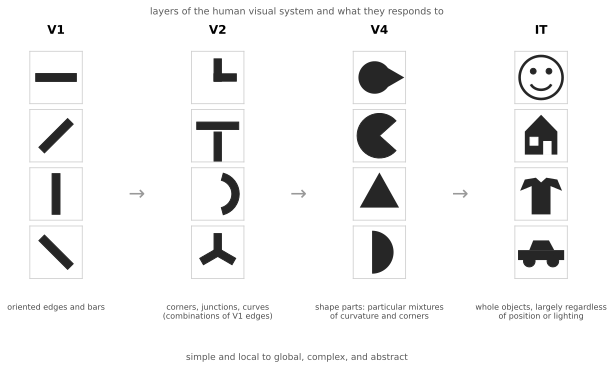

In [15]:
# preferred stimuli at each stage, drawn schematically
def v2_corner(ax):
    ray(ax, 0); ray(ax, 90)

def v2_tee(ax):
    bar(ax, 0, length=1.6, width=0.28, y0=0.38); ray(ax, -90, length=1.15)

def v2_arc(ax):
    ax.add_patch(Wedge((0, 0), 0.82, -75, 75, width=0.28, color=INK))

def v2_fork(ax):
    for deg in (90, 210, 330):
        ray(ax, deg)

def v4_teardrop(ax):        # a sharp point at one end, smooth at the other
    arc = curve_pts(lambda t: 0.62 * np.ones_like(t), 0.62, 2 * np.pi - 0.62)
    poly(ax, np.vstack([[[0.95, 0.0]], arc - [0.18, 0]]))

def v4_wedge(ax):           # a concave notch between two sharp corners
    ax.add_patch(Wedge((0, 0), 0.85, 42, 318, color=INK))

def v4_triangle(ax):        # corners only, no curvature
    poly(ax, [(0, 0.82), (0.75, -0.52), (-0.75, -0.52)])

def v4_dshape(ax):          # one straight edge joined to one smooth bulge
    arc = curve_pts(lambda t: 0.82 * np.ones_like(t), -np.pi / 2, np.pi / 2)
    poly(ax, np.vstack([[[-0.28, 0.82]], arc + [-0.28, 0], [[-0.28, -0.82]]]))

def it_face(ax):
    ax.add_patch(Circle((0, 0), 0.82, fill=False, lw=2.6, edgecolor=INK))
    ax.add_patch(Circle((-0.3, 0.24), 0.11, color=INK))
    ax.add_patch(Circle((0.3, 0.24), 0.11, color=INK))
    ax.add_patch(Arc((0, -0.12), 0.85, 0.7, theta1=200, theta2=340, lw=2.6,
                     edgecolor=INK))

def it_house(ax):
    poly(ax, [(-0.62, -0.72), (-0.62, 0.16), (0, 0.8), (0.62, 0.16),
              (0.62, -0.72)])
    ax.add_patch(Rectangle((0.1, -0.72), 0.28, 0.5, color='white'))
    ax.add_patch(Rectangle((-0.42, -0.36), 0.3, 0.3, color='white'))

def it_shirt(ax):
    poly(ax, [(-0.36, -0.78), (0.36, -0.78), (0.36, 0.3), (0.8, 0.12),
              (0.62, 0.55), (0.2, 0.62), (0, 0.44), (-0.2, 0.62),
              (-0.62, 0.55), (-0.8, 0.12), (-0.36, 0.3)])

def it_car(ax):
    poly(ax, [(-0.88, -0.3), (-0.88, 0.08), (0.88, 0.08), (0.88, -0.3)])
    poly(ax, [(-0.45, 0.08), (-0.3, 0.45), (0.3, 0.45), (0.5, 0.08)])
    ax.add_patch(Circle((-0.45, -0.34), 0.22, color=INK))
    ax.add_patch(Circle((0.45, -0.34), 0.22, color=INK))

stages = [
    ('V1', 'oriented edges and bars',
     [lambda ax: bar(ax, 0), lambda ax: bar(ax, 45),
      lambda ax: bar(ax, 90), lambda ax: bar(ax, 135)]),
    ('V2', 'corners, junctions, curves\n(combinations of V1 edges)',
     [v2_corner, v2_tee, v2_arc, v2_fork]),
    ('V4', 'shape parts: particular mixtures\nof curvature and corners',
     [v4_teardrop, v4_wedge, v4_triangle, v4_dshape]),
    ('IT', 'whole objects, largely regardless\nof position or lighting',
     [it_face, it_house, it_shirt, it_car]),
]

fig = plt.figure(figsize=(9.5, 5.4))
col_x = np.linspace(0.09, 0.80, 4)
w, h = 0.115, 0.135
for x, (name, what, stimuli) in zip(col_x, stages):
    fig.text(x + w / 2, 0.915, name, ha='center', fontsize=12,
             fontweight='bold')
    fig.text(x + w / 2, 0.22, what, ha='center', va='top', fontsize=8,
             color='0.3')
    for y, draw in zip([0.735, 0.585, 0.435, 0.285], stimuli):
        ax = fig.add_axes([x, y, w, h])
        blank(ax)
        draw(ax)

for x0, x1 in zip(col_x[:-1], col_x[1:]):
    fig.text((x0 + w + x1) / 2, 0.50, '$\\rightarrow$', ha='center',
             va='center', fontsize=20, color='0.6')

fig.text(0.5, 0.965, 'layers of the human visual system and what they responds to', ha='center',
         fontsize=9.5, color='0.35')
fig.text(0.5, 0.075,
         'simple and local to global, complex, and abstract',
         ha='center', fontsize=9, color='0.35');

Read the figure left to right and the story is one of *composition*: nothing in a layer is detected directly, only assembled from the layer preceding it.  (The drawings are schematic — real V2 and V4 preferences are messier than corners and teardrops — but the progression from simple and local to complex and abstract is the well-established part, and it is the aspect we are going to copy.)

Receptive fields grow along the way, and now we can say why they must.  A neuron that responds to a face has to have a face-sized receptive field, and it gets one by pooling over neurons that feed it, each with a smaller window.  **Reach is accumulated by stacking.**  That is the opposite of a fully connected layer.

Two properties, then, are worth taking as design cues:

**Local receptive fields.**  Every unit reads a small patch, and larger structure is reached by stacking rather than by any single unit looking at everything.

**The same detector, everywhere.**  V1 is not one edge detector; it is an array of near-identical edge detectors tiling the visual field.  There is nothing special about the top left of a scene that would demand a different edge detector from the bottom right.  Put statistically: *a feature worth computing in one part of an image is worth computing everywhere in it*.  And if the detectors are the same, we should not learn them separately — we should learn one set of weights and **share** it across all positions.

Now count what those two ideas would save us.  Suppose a hidden unit reads a $3 \times 3$ patch instead of the whole image, and suppose every unit computing the same kind of feature shares one set of weights:

       image     fully connected    local + shared
       28x28             784,000               576
     128x128          16,384,000               576
   1024x1024       1,048,576,000               576


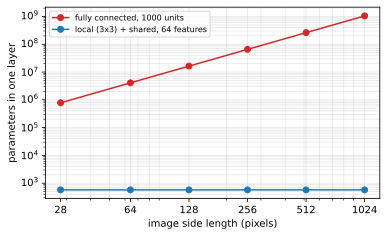

In [16]:
def dense_params(side, hidden=1000):
    """Weights in a fully connected layer over a side x side image."""
    return side ** 2 * hidden

def local_shared_params(side, num_features=64, patch=3):
    """Weights when each unit reads a patch x patch region and units computing
    the same feature share their weights."""
    return num_features * patch ** 2      # note: no dependence on `side`

print(f'{"image":>12s}  {"fully connected":>18s}  {"local + shared":>16s}')
for n in (28, 128, 1024):
    print(f'{f"{n}x{n}":>12s}  {dense_params(n):>18,d}  '
          f'{local_shared_params(n):>16,d}')

fig, ax = plt.subplots(figsize=(5.5, 3.4))
sides = np.array([28, 64, 128, 256, 512, 1024])
ax.loglog(sides, [dense_params(n) for n in sides], 'o-', color='C3',
          label='fully connected, 1000 units')
ax.loglog(sides, [local_shared_params(n) for n in sides], 'o-', color='C0',
          label='local (3x3) + shared, 64 features')
ax.set_xlabel('image side length (pixels)')
ax.set_ylabel('parameters in one layer')
ax.set_xticks(sides); ax.set_xticklabels(sides)
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8)
fig.tight_layout()

The blue line is flat.  Locality caps how many weights a unit needs regardless of how large the image is, and sharing means adding positions costs nothing at all — a layer for a megapixel photograph has exactly as many parameters as one for a thumbnail.  Six orders of magnitude at $1024 \times 1024$, and the gap widens without limit.

Notice, too, that the two ideas address the *other* two problems at the same time.  Sharing one detector across all positions is precisely what makes the response to a feature independent of where the feature sits — the invariance that pixel distance so badly lacked.  And a unit that reads a patch is reading pixels *because they are adjacent*, which is the structure a permuted-pixel MLP could not use.  All three complaints, one answer.

A caution before we go on.  Analogies between deep networks and brains are easy to overdraw: the resemblance is real at the first layer and becomes progressively more metaphorical after that, and backpropagation is certainly not how the cortex learns.  Biology is being used here as a source of design ideas, not as evidence that the ideas are correct.  What makes them correct is that they work.

## Two principles

Here is the design brief, distilled from everything above:

1. **Translation invariance.**  In the earliest layers, the network should respond the same way to the same local pattern regardless of where it appears.  (What we will actually build is translation *equivariance*: move the input and the response moves with it.  Genuine invariance comes later, from pooling.)
2. **Locality.**  The earliest layers should look only at small neighborhoods, ignoring distant parts of the image.  Local descriptions get combined into larger ones with depth, so that later layers respond to large, abstract structure — the hierarchy above.

Two principles, both suggested by biology, both defensible on statistical grounds, and both flatly violated by a fully connected layer.

Notice how little we have specified.  Nothing above says "convolution", or mentions a sliding window, or a kernel.  Yet in the next notebook we will write down the operation that satisfies these principles — and then discover, at the end of it, that these two requirements do not merely *permit* a convolution.  They force one.

## Summary

* Pixel space is a poor representation of image content: a digit is closer to a *different digit* than to a shifted copy of itself, and averaged over a dataset, a shift of a few pixels exceeds the distance to the nearest image of another class.
* A fully connected network is provably blind to spatial arrangement.  Training on images with a fixed pixel permutation gives the same accuracy as training on the originals, because the two problems are the same problem.
* Dense connectivity does not scale.  One layer over a $28 \times 28$ thumbnail costs 200,704 weights; over a megapixel image, $10^9$.  The count grows with image *area*.
* Biological vision is a hierarchy of increasing abstraction: V1 neurons prefer oriented edges, and each stage above responds to patterns *composed* of the stage below, up to whole objects in IT.  It suggests two ingredients: **local receptive fields**, small at first and growing with depth so that reach comes from stacking, and **the same detector repeated across the visual field** — that is, weight sharing.
* Together those make a layer's parameter count independent of image size, while also delivering the position-independence that pixel distance lacked.
* They become our design principles: **translation invariance** and **locality**.  The next notebook builds the operation that satisfies them.

## Exercises

1. Repeat the digit comparison with rotations instead of shifts (`torchvision.transforms.functional.rotate`), and with a change in brightness (add a constant to every pixel).  Which transformation moves an image farthest in pixel space, and does that ranking match your sense of which is the biggest change?
2. Rerun the permutation experiment with a *local* permutation — shuffle pixels only within each $4 \times 4$ block — and compare it with the global one.  Predict the MLP's behaviour before running it.  Then predict a CNN's, and revisit after notebook 6.
3. The permutation argument shows the two learning problems are equivalent.  Write out why explicitly, in terms of the first weight matrix.  Would the argument still hold if the network's first layer had local receptive fields?
4. In the animation, the dense layer needs $784 \times 256$ weights.  How many would be needed if each of the 256 hidden units read only a $3 \times 3$ patch but the weights were **not** shared between positions?  How many with sharing?  Which of the two ideas — locality or sharing — saves more here, and does your answer change at $1024 \times 1024$?
5. Why might translation invariance be a bad assumption?  Describe a vision task where absolute position in the frame carries real information, and say what you would do about it.
6. Receptive fields grow with depth because each neuron pools over several neurons preceding it.  Suppose each stage enlarges the receptive field by only 2 pixels.  How many stages would it take to see all of a $1024 \times 1024$ image?  What does that suggest is missing from the story so far?  (Notebooks 3 and 5 supply it.)
7. Audio is a one-dimensional signal and text a one-dimensional sequence.  What are the analogues of translation invariance and locality in each?  Where does the analogy break down for text?